#Question-4


## Vanilla RNNs, BPTT, and LSTMs for Sentiment Analysis

This notebook presents a full from-scratch implementation of sequence learning models using only standard Python and NumPy. The goal is to solve a many-to-one sequence classification problem using the IMDb Movie Reviews dataset for binary sentiment analysis.

The notebook includes:

1. Dataset preparation and preprocessing  
2. Input representation using one-hot vectors and learned embeddings  
3. Vanilla RNN forward pass  
4. Backpropagation Through Time (BPTT)  
5. Gradient clipping for exploding gradients  
6. LSTM implementation from scratch  
7. Ablation studies:
   - Vanishing gradient analysis
   - Coupled input-forget gate LSTM
   - Optimization comparison: SGD vs Adam

We report Accuracy and F1-score and compare performance across models, sequence lengths, and optimizers.

## 1. Importing Required Libraries

In this section, we import the Python libraries required for numerical computation, plotting, and timing experiments.

- `numpy` is used for all matrix and vector operations.
- `matplotlib` is used for plotting loss curves and ablation results.
- `time` is used to measure training time for comparisons.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import time


## 2. Loading the IMDb Dataset

We use the IMDb Movie Reviews dataset for binary sentiment classification.

Each review is represented as a sequence of word indices, and each label is binary:

- `1` = positive sentiment  
- `0` = negative sentiment

A preprocessed version of the dataset is used, which already provides tokenized reviews as integer sequences. This is allowed by the assignment, provided that preprocessing choices are documented clearly.

In [2]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

## 3. Experimental Configuration

We now define the main hyperparameters used throughout the notebook.

Important settings include:

- Vocabulary size
- Embedding dimension
- Hidden dimension
- Number of training, validation, and test samples
- Sequence lengths used for ablation studies

These values are chosen so that the implementation remains computationally feasible in a NumPy-only setting while still demonstrating the required behavior of RNNs and LSTMs.

In [3]:
VOCAB_SIZE = 5000
EMBED_DIM = 50
HIDDEN_DIM = 64
OUTPUT_DIM = 1

TRAIN_SAMPLES = 4000
VAL_SAMPLES = 500
TEST_SAMPLES = 500

SEQ_LENGTHS = [5, 20, 50]

PAD_TOKEN = 0
UNK_TOKEN = 2

np.random.seed(42)

## 4. Train, Validation, and Test Split

The assignment requires splitting the dataset into training, validation, and test sets.

We use:

- Training set: used to update model parameters
- Validation set: used to monitor generalization and convergence
- Test set: used only for final evaluation

This follows the standard evaluation protocol required in the question.

In [4]:
# Load preprocessed IMDb dataset (integer token sequences)
(x_train_full, y_train_full), (x_test_full, y_test_full) = imdb.load_data(num_words=VOCAB_SIZE)

# Subsample to keep runtime manageable
x_train_full = x_train_full[:TRAIN_SAMPLES + VAL_SAMPLES]
y_train_full = y_train_full[:TRAIN_SAMPLES + VAL_SAMPLES]

x_test_full = x_test_full[:TEST_SAMPLES]
y_test_full = y_test_full[:TEST_SAMPLES]

# Split train / validation
x_train_raw = x_train_full[:TRAIN_SAMPLES]
y_train = y_train_full[:TRAIN_SAMPLES]

x_val_raw = x_train_full[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]
y_val = y_train_full[TRAIN_SAMPLES:TRAIN_SAMPLES + VAL_SAMPLES]

x_test_raw = x_test_full
y_test = y_test_full

print("Train:", len(x_train_raw))
print("Validation:", len(x_val_raw))
print("Test:", len(x_test_raw))

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: 4000
Validation: 500
Test: 500


## 5. Sequence Handling: Padding and Truncation

Sequence models require inputs of consistent length during training.

Therefore, we fix a maximum sequence length \(T\). Then:

- Reviews longer than \(T\) are truncated
- Reviews shorter than \(T\) are padded using the special padding token

This satisfies the assignment requirement of handling variable-length sequences through fixed-length input representations.

In [5]:
def prepare_sequences(sequences, max_len):
    return pad_sequences(
        sequences,
        maxlen=max_len,
        padding='post',
        truncating='post',
        value=PAD_TOKEN
    )

## 6. Evaluation Metrics

The assignment asks us to report the following evaluation metrics on the test set:

1. **Accuracy**
2. **F1-score**

### Accuracy
Accuracy is the fraction of correctly classified samples:

\[
\text{Accuracy} = \frac{\text{Number of correct predictions}}{\text{Total number of predictions}}
\]

### F1-Score
The F1-score is the harmonic mean of precision and recall:

\[
\text{Precision} = \frac{TP}{TP + FP}
\]

\[
\text{Recall} = \frac{TP}{TP + FN}
\]

\[
F1 = \frac{2 \cdot \text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}
\]

The F1-score is especially useful in binary classification when we want a balanced measure of performance.

In [6]:
def accuracy_score(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    return np.mean(y_true == y_pred)

def f1_score_binary(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    tp = np.sum((y_true == 1) & (y_pred == 1))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))

    precision = tp / (tp + fp + 1e-12)
    recall = tp / (tp + fn + 1e-12)

    return 2 * precision * recall / (precision + recall + 1e-12)

## 7. Activation Functions and Loss Function

We now define the nonlinear activation functions and loss function used in the models.

### Sigmoid Function
For binary classification, the output layer uses the sigmoid activation:

\[
\sigma(z) = \frac{1}{1 + e^{-z}}
\]

This maps the output to the interval \((0,1)\), which can be interpreted as the probability of the positive class.

### Tanh Function
The hidden state update in the Vanilla RNN uses the hyperbolic tangent function:

\[
\tanh(z) = \frac{e^z - e^{-z}}{e^z + e^{-z}}
\]

### Binary Cross-Entropy Loss
Since the task is binary classification, we use binary cross-entropy loss:

\[
L = -\left[y \log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
\]

where:

- \(y\) is the true label
- \(\hat{y}\) is the predicted probability

The derivative of the loss with respect to the output logits simplifies to:

\[
\frac{\partial L}{\partial z} = \hat{y} - y
\]

which makes backpropagation easier to implement.

In [7]:
def sigmoid(x):
    x = np.clip(x, -50, 50)
    return 1.0 / (1.0 + np.exp(-x))

def tanh(x):
    return np.tanh(x)

def dtanh_from_output(h):
    return 1.0 - h**2

def binary_cross_entropy(y_hat, y):
    y_hat = np.clip(y_hat, 1e-12, 1 - 1e-12)
    return -(y * np.log(y_hat) + (1 - y) * np.log(1 - y_hat))

def binary_cross_entropy_grad(y_hat, y):
    return y_hat - y

## 8. Mini-batch Utility

Although the training loop in this notebook updates one sample at a time for simplicity, it is useful to define a mini-batch generator for extensibility.

Shuffling is performed at every epoch so that the model does not see the training data in the same fixed order repeatedly.

In [8]:
def create_batches(X, y, batch_size=16, shuffle=True):
    indices = np.arange(len(X))
    if shuffle:
        np.random.shuffle(indices)

    for start in range(0, len(X), batch_size):
        batch_idx = indices[start:start + batch_size]
        yield X[batch_idx], y[batch_idx]

## 9. Vanilla RNN: Forward Pass

We now implement the standard Vanilla Recurrent Neural Network from scratch.

At time step \(t\), the hidden state is updated as:

\[
h_t = \tanh(W_{xh}x_t + W_{hh}h_{t-1} + b_h)
\]

where:

- \(x_t\) is the input vector at time step \(t\)
- \(h_{t-1}\) is the previous hidden state
- \(W_{xh}\) is the input-to-hidden weight matrix
- \(W_{hh}\) is the hidden-to-hidden recurrent weight matrix
- \(b_h\) is the hidden bias

The initial hidden state is:

\[
h_0 = 0
\]

Since this is a **many-to-one** sequence task, only the final hidden state \(h_T\) is used for classification.

The output layer is:

\[
z = W_{hy}h_T + b_y
\]

\[
\hat{y} = \sigma(z)
\]

This output \(\hat{y}\) represents the predicted probability that the review is positive.

## 10. Backpropagation Through Time (BPTT)

To train the Vanilla RNN, we implement Backpropagation Through Time (BPTT).

Since the same recurrent weights are reused at every time step, the total gradient is the sum of contributions from all time steps.

For the output layer:

\[
\frac{\partial L}{\partial z} = \hat{y} - y
\]

\[
\frac{\partial L}{\partial W_{hy}} = \frac{\partial L}{\partial z} h_T^T
\]

\[
\frac{\partial L}{\partial b_y} = \frac{\partial L}{\partial z}
\]

For the hidden layer, the gradient is propagated backward through time.

At time step \(t\):

\[
a_t = W_{xh}x_t + W_{hh}h_{t-1} + b_h
\]

\[
h_t = \tanh(a_t)
\]

Hence,

\[
\frac{\partial L}{\partial a_t} = \frac{\partial L}{\partial h_t} \odot (1 - h_t^2)
\]

Then,

\[
\frac{\partial L}{\partial W_{xh}} += \frac{\partial L}{\partial a_t}x_t^T
\]

\[
\frac{\partial L}{\partial W_{hh}} += \frac{\partial L}{\partial a_t}h_{t-1}^T
\]

\[
\frac{\partial L}{\partial b_h} += \frac{\partial L}{\partial a_t}
\]

and the gradient passed to the previous hidden state is:

\[
\frac{\partial L}{\partial h_{t-1}} = W_{hh}^T \frac{\partial L}{\partial a_t}
\]

This repeated multiplication across time steps is the main reason why Vanilla RNNs suffer from vanishing and exploding gradients.

In [9]:
class VanillaRNN:
    def __init__(self, vocab_size, embed_dim, hidden_dim, use_embedding=True):
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.use_embedding = use_embedding

        input_dim = embed_dim if use_embedding else vocab_size

        if use_embedding:
            self.E = np.random.randn(vocab_size, embed_dim) * 0.01

        self.Wxh = np.random.randn(hidden_dim, input_dim) * 0.1
        self.Whh = np.random.randn(hidden_dim, hidden_dim) * 0.1
        self.bh = np.zeros((hidden_dim, 1))

        self.Why = np.random.randn(1, hidden_dim) * 0.1
        self.by = np.zeros((1, 1))

        self.params = self.get_params()

    def get_params(self):
        params = {
            "Wxh": self.Wxh,
            "Whh": self.Whh,
            "bh": self.bh,
            "Why": self.Why,
            "by": self.by
        }
        if self.use_embedding:
            params["E"] = self.E
        return params

    def zero_grads(self):
        grads = {}
        for k, v in self.params.items():
            grads["d" + k] = np.zeros_like(v)
        return grads

    def one_hot(self, idx):
        x = np.zeros((self.vocab_size, 1))
        x[idx] = 1.0
        return x

    def get_input_vector(self, idx):
        if self.use_embedding:
            return self.E[idx].reshape(-1, 1)
        else:
            return self.one_hot(idx)

    def forward(self, seq):
        h_prev = np.zeros((self.hidden_dim, 1))
        xs = []
        hs = [h_prev]
        word_ids = []

        for idx in seq:
            idx = int(idx)
            x_t = self.get_input_vector(idx)
            h_t = tanh(self.Wxh @ x_t + self.Whh @ h_prev + self.bh)

            xs.append(x_t)
            hs.append(h_t)
            word_ids.append(idx)
            h_prev = h_t

        h_T = hs[-1]
        logits = self.Why @ h_T + self.by
        y_hat = sigmoid(logits)

        cache = {
            "xs": xs,
            "hs": hs,
            "word_ids": word_ids,
            "y_hat": y_hat
        }
        return y_hat, cache

    def backward(self, y, cache, clip_value=5.0):
        grads = self.zero_grads()

        xs = cache["xs"]
        hs = cache["hs"]
        y_hat = cache["y_hat"]
        word_ids = cache["word_ids"]

        dlogits = binary_cross_entropy_grad(y_hat, y)

        grads["dWhy"] += dlogits @ hs[-1].T
        grads["dby"] += dlogits

        dh = self.Why.T @ dlogits

        grad_h1_mag = None

        for t in reversed(range(len(xs))):
            h_t = hs[t + 1]
            h_prev = hs[t]
            x_t = xs[t]

            da = dh * dtanh_from_output(h_t)

            grads["dWxh"] += da @ x_t.T
            grads["dWhh"] += da @ h_prev.T
            grads["dbh"] += da

            dx = self.Wxh.T @ da
            dh = self.Whh.T @ da

            if self.use_embedding:
                grads["dE"][word_ids[t]] += dx.reshape(-1)

            if t == 0:
                grad_h1_mag = np.linalg.norm(dh)

        for k in grads:
            np.clip(grads[k], -clip_value, clip_value, out=grads[k])

        return grads, grad_h1_mag

## 11. Gradient Clipping

During BPTT, gradients may explode because they are repeatedly multiplied through the recurrent structure.

To avoid instability and prevent the loss from becoming NaN, we apply gradient clipping:

\[
g \leftarrow \text{clip}(g, -c, c)
\]

where \(c\) is the clipping threshold.

In this notebook, all gradients are clipped to the interval:

\[
[-5, 5]
\]

This is a standard technique for stabilizing RNN training.

## 12. LSTM Implementation

Vanilla RNNs often fail to capture long-term dependencies because gradients vanish over long sequences. To address this problem, we implement a Long Short-Term Memory (LSTM) network.

An LSTM maintains two states:

- hidden state \(h_t\)
- cell state \(C_t\)

The cell state provides a more stable path for gradient flow.

### Forget Gate
The forget gate determines how much of the previous cell state should be retained:

\[
f_t = \sigma(W_f [h_{t-1}, x_t] + b_f)
\]

### Input Gate
The input gate determines how much new information should be written into the cell:

\[
i_t = \sigma(W_i [h_{t-1}, x_t] + b_i)
\]

### Candidate Cell State
A candidate update is computed as:

\[
\tilde{C}_t = \tanh(W_c [h_{t-1}, x_t] + b_c)
\]

### Cell State Update
The new cell state is:

\[
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
\]

### Output Gate
The output gate determines what part of the cell state is exposed to the hidden state:

\[
o_t = \sigma(W_o [h_{t-1}, x_t] + b_o)
\]

### Hidden State Update
Finally,

\[
h_t = o_t \odot \tanh(C_t)
\]

This architecture allows the model to preserve relevant information over longer time horizons.

## 13. Backward Pass in LSTM

In the LSTM, gradients flow not only through the hidden state but also through the cell state.

This is the key reason why LSTMs mitigate the vanishing gradient problem more effectively than Vanilla RNNs.

In particular, the cell update is additive:

\[
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
\]

Because of this additive structure, the gradient can propagate through the cell state with less repeated shrinkage compared to the recurrent multiplication in a Vanilla RNN.

The backward pass computes gradients for:

- forget gate parameters
- input gate parameters
- candidate cell state parameters
- output gate parameters
- output layer parameters
- embedding matrix (if learned embeddings are used)

In [10]:
class LSTM:
    def __init__(self, vocab_size, embed_dim, hidden_dim, use_embedding=True, coupled=False):
        self.vocab_size = vocab_size
        self.embed_dim = embed_dim
        self.hidden_dim = hidden_dim
        self.use_embedding = use_embedding
        self.coupled = coupled

        input_dim = embed_dim if use_embedding else vocab_size
        z_dim = hidden_dim + input_dim

        if use_embedding:
            self.E = np.random.randn(vocab_size, embed_dim) * 0.01

        self.Wf = np.random.randn(hidden_dim, z_dim) * 0.1
        self.bf = np.zeros((hidden_dim, 1))

        if not coupled:
            self.Wi = np.random.randn(hidden_dim, z_dim) * 0.1
            self.bi = np.zeros((hidden_dim, 1))

        self.Wc = np.random.randn(hidden_dim, z_dim) * 0.1
        self.bc = np.zeros((hidden_dim, 1))

        self.Wo = np.random.randn(hidden_dim, z_dim) * 0.1
        self.bo = np.zeros((hidden_dim, 1))

        self.Why = np.random.randn(1, hidden_dim) * 0.1
        self.by = np.zeros((1, 1))

        self.params = self.get_params()

    def get_params(self):
        params = {
            "Wf": self.Wf, "bf": self.bf,
            "Wc": self.Wc, "bc": self.bc,
            "Wo": self.Wo, "bo": self.bo,
            "Why": self.Why, "by": self.by
        }
        if not self.coupled:
            params["Wi"] = self.Wi
            params["bi"] = self.bi
        if self.use_embedding:
            params["E"] = self.E
        return params

    def zero_grads(self):
        grads = {}
        for k, v in self.params.items():
            grads["d" + k] = np.zeros_like(v)
        return grads

    def one_hot(self, idx):
        x = np.zeros((self.vocab_size, 1))
        x[idx] = 1.0
        return x

    def get_input_vector(self, idx):
        if self.use_embedding:
            return self.E[idx].reshape(-1, 1)
        else:
            return self.one_hot(idx)

    def forward(self, seq):
        h = np.zeros((self.hidden_dim, 1))
        c = np.zeros((self.hidden_dim, 1))

        xs = []
        zs = []
        fs = []
        is_ = []
        c_tildes = []
        os_ = []
        hs = [h]
        cs = [c]
        word_ids = []

        for idx in seq:
            idx = int(idx)
            x = self.get_input_vector(idx)
            z = np.vstack([h, x])

            f = sigmoid(self.Wf @ z + self.bf)

            if self.coupled:
                i = 1.0 - f
            else:
                i = sigmoid(self.Wi @ z + self.bi)

            c_tilde = tanh(self.Wc @ z + self.bc)
            c = f * c + i * c_tilde
            o = sigmoid(self.Wo @ z + self.bo)
            h = o * tanh(c)

            xs.append(x)
            zs.append(z)
            fs.append(f)
            is_.append(i)
            c_tildes.append(c_tilde)
            os_.append(o)
            hs.append(h)
            cs.append(c)
            word_ids.append(idx)

        logits = self.Why @ hs[-1] + self.by
        y_hat = sigmoid(logits)

        cache = {
            "xs": xs,
            "zs": zs,
            "fs": fs,
            "is": is_,
            "c_tildes": c_tildes,
            "os": os_,
            "hs": hs,
            "cs": cs,
            "word_ids": word_ids,
            "y_hat": y_hat
        }
        return y_hat, cache

    def backward(self, y, cache, clip_value=5.0):
        grads = self.zero_grads()

        zs = cache["zs"]
        fs = cache["fs"]
        is_ = cache["is"]
        c_tildes = cache["c_tildes"]
        os_ = cache["os"]
        hs = cache["hs"]
        cs = cache["cs"]
        word_ids = cache["word_ids"]
        y_hat = cache["y_hat"]

        dlogits = binary_cross_entropy_grad(y_hat, y)

        grads["dWhy"] += dlogits @ hs[-1].T
        grads["dby"] += dlogits

        dh_next = self.Why.T @ dlogits
        dc_next = np.zeros((self.hidden_dim, 1))

        grad_h1_mag = None

        for t in reversed(range(len(zs))):
            z = zs[t]
            f = fs[t]
            i = is_[t]
            c_tilde = c_tildes[t]
            o = os_[t]
            h_t = hs[t + 1]
            c_t = cs[t + 1]
            c_prev = cs[t]

            tanh_c = tanh(c_t)

            do = dh_next * tanh_c
            do_raw = do * o * (1.0 - o)

            dc = dh_next * o * (1.0 - tanh_c**2) + dc_next

            if self.coupled:
                df = dc * (c_prev - c_tilde)
                dc_tilde = dc * (1.0 - f)
            else:
                di = dc * c_tilde
                df = dc * c_prev
                dc_tilde = dc * i

            df_raw = df * f * (1.0 - f)
            dc_tilde_raw = dc_tilde * (1.0 - c_tilde**2)

            grads["dWf"] += df_raw @ z.T
            grads["dbf"] += df_raw

            if not self.coupled:
                di_raw = di * i * (1.0 - i)
                grads["dWi"] += di_raw @ z.T
                grads["dbi"] += di_raw

            grads["dWc"] += dc_tilde_raw @ z.T
            grads["dbc"] += dc_tilde_raw

            grads["dWo"] += do_raw @ z.T
            grads["dbo"] += do_raw

            dz = self.Wf.T @ df_raw + self.Wc.T @ dc_tilde_raw + self.Wo.T @ do_raw
            if not self.coupled:
                dz += self.Wi.T @ di_raw

            dh_next = dz[:self.hidden_dim, :]
            dx = dz[self.hidden_dim:, :]
            dc_next = dc * f

            if self.use_embedding:
                grads["dE"][word_ids[t]] += dx.reshape(-1)

            if t == 0:
                grad_h1_mag = np.linalg.norm(dh_next)

        for k in grads:
            np.clip(grads[k], -clip_value, clip_value, out=grads[k])

        return grads, grad_h1_mag

## 14. Optimization Methods: SGD and Adam

The assignment requires comparing two optimization strategies:

### Stochastic Gradient Descent (SGD)

In SGD, parameters are updated as:

\[
w \leftarrow w - \eta \nabla_w L
\]

where:

- \(w\) is a parameter
- \(\eta\) is the learning rate
- \(\nabla_w L\) is the gradient of the loss with respect to that parameter

### Adam Optimizer

Adam maintains exponentially decaying averages of:

- first moment (mean of gradients)
- second moment (mean of squared gradients)

The updates are:

\[
m_t = \beta_1 m_{t-1} + (1-\beta_1)g_t
\]

\[
v_t = \beta_2 v_{t-1} + (1-\beta_2)g_t^2
\]

Because both \(m_t\) and \(v_t\) start at zero, bias correction is necessary:

\[
\hat{m}_t = \frac{m_t}{1-\beta_1^t}
\]

\[
\hat{v}_t = \frac{v_t}{1-\beta_2^t}
\]

Finally, the Adam update rule is:

\[
w \leftarrow w - \eta \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}
\]

Adam is often more stable and converges faster than plain SGD, especially for recurrent networks.

In [11]:
class SGD:
    def __init__(self, lr=0.01):
        self.lr = lr

    def step(self, params, grads):
        for k in params:
            params[k] -= self.lr * grads["d" + k]


class Adam:
    def __init__(self, params, lr=0.001, beta1=0.9, beta2=0.999, eps=1e-8):
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.eps = eps
        self.t = 0

        self.m = {}
        self.v = {}
        for k, val in params.items():
            self.m[k] = np.zeros_like(val)
            self.v[k] = np.zeros_like(val)

    def step(self, params, grads):
        self.t += 1
        for k in params:
            g = grads["d" + k]

            self.m[k] = self.beta1 * self.m[k] + (1 - self.beta1) * g
            self.v[k] = self.beta2 * self.v[k] + (1 - self.beta2) * (g ** 2)

            m_hat = self.m[k] / (1 - self.beta1 ** self.t)
            v_hat = self.v[k] / (1 - self.beta2 ** self.t)

            params[k] -= self.lr * m_hat / (np.sqrt(v_hat) + self.eps)

## 15. Prediction and Model Evaluation

After training, we evaluate the models on validation and test data.

For each sequence:

1. A forward pass computes the predicted probability
2. The probability is converted to a class label using threshold \(0.5\)
3. Accuracy and F1-score are computed over the dataset

In [12]:
def predict_dataset(model, X):
    preds = []
    probs = []

    for seq in X:
        y_hat, _ = model.forward(seq)
        prob = float(y_hat.squeeze())
        pred = 1 if prob >= 0.5 else 0
        preds.append(pred)
        probs.append(prob)

    return np.array(preds), np.array(probs)


def evaluate_model(model, X, y):
    preds, probs = predict_dataset(model, X)

    losses = []
    for i in range(len(X)):
        yy = np.array([[y[i]]], dtype=np.float32)
        p = np.array([[probs[i]]], dtype=np.float32)
        losses.append(float(binary_cross_entropy(p, yy)))

    acc = accuracy_score(y, preds)
    f1 = f1_score_binary(y, preds)
    avg_loss = np.mean(losses)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "f1": f1
    }

## 16. Training Procedure

The training loop performs the following steps for each epoch:

1. Shuffle the training data
2. Perform a forward pass for each sequence
3. Compute the binary cross-entropy loss
4. Perform backward propagation
5. Apply gradient clipping
6. Update parameters using the selected optimizer
7. Evaluate the model on the validation set

The notebook stores:

- training loss
- validation loss
- training accuracy
- validation accuracy
- training F1-score
- validation F1-score

These will later be used to plot convergence curves.

In [13]:
def train_model(model, X_train, y_train, X_val, y_val, optimizer_name="sgd", lr=0.01, epochs=5, batch_size=1):
    if optimizer_name.lower() == "sgd":
        optimizer = SGD(lr=lr)
    elif optimizer_name.lower() == "adam":
        optimizer = Adam(model.params, lr=lr)
    else:
        raise ValueError("optimizer_name must be 'sgd' or 'adam'")

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_acc": [],
        "val_acc": [],
        "train_f1": [],
        "val_f1": []
    }

    for epoch in range(epochs):
        epoch_losses = []

        indices = np.arange(len(X_train))
        np.random.shuffle(indices)
        X_train = X_train[indices]
        y_train = y_train[indices]

        for i in range(len(X_train)):
            seq = X_train[i]
            label = y_train[i]

            y = np.array([[label]], dtype=np.float32)

            y_hat, cache = model.forward(seq)
            loss = float(binary_cross_entropy(y_hat, y))
            epoch_losses.append(loss)

            grads, _ = model.backward(y, cache, clip_value=5.0)
            optimizer.step(model.params, grads)

        train_metrics = evaluate_model(model, X_train[:300], y_train[:300])
        val_metrics = evaluate_model(model, X_val, y_val)

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["train_acc"].append(train_metrics["accuracy"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["train_f1"].append(train_metrics["f1"])
        history["val_f1"].append(val_metrics["f1"])

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Train Acc: {train_metrics['accuracy']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f}"
        )

    return history

## 17. Visualization Functions

To study convergence behavior, we plot:

- loss curves
- accuracy curves
- F1-score curves

These plots help compare optimization methods and architectural variants, as required in the assignment.

In [14]:
def plot_loss_curves(history, title="Loss Curves"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_loss"], marker='o', label="Train Loss")
    plt.plot(history["val_loss"], marker='s', label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_accuracy_curves(history, title="Accuracy Curves"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_acc"], marker='o', label="Train Accuracy")
    plt.plot(history["val_acc"], marker='s', label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()


def plot_f1_curves(history, title="F1 Curves"):
    plt.figure(figsize=(8, 5))
    plt.plot(history["train_f1"], marker='o', label="Train F1")
    plt.plot(history["val_f1"], marker='s', label="Validation F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()

## 18. Experiment 1: Vanilla RNN with Learned Embeddings

In this experiment, the input words are represented using a learned embedding matrix:

\[
E \in \mathbb{R}^{|V| \times d}
\]

Each word index \(w_t\) is mapped to a dense vector:

\[
x_t = E[w_t]
\]

This approach is more compact than one-hot encoding and usually allows the model to learn more meaningful semantic representations.

/tmp/ipykernel_16637/1848786341.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss = float(binary_cross_entropy(y_hat, y))
/tmp/ipykernel_16637/691033615.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  losses.append(float(binary_cross_entropy(p, yy)))


Epoch 1/5 | Train Loss: 0.6968 | Val Loss: 0.7148 | Train Acc: 0.4800 | Val Acc: 0.4720 | Val F1: 0.0000
Epoch 2/5 | Train Loss: 0.6367 | Val Loss: 0.6910 | Train Acc: 0.7267 | Val Acc: 0.5520 | Val F1: 0.6000
Epoch 3/5 | Train Loss: 0.5053 | Val Loss: 0.7643 | Train Acc: 0.7733 | Val Acc: 0.5320 | Val F1: 0.5699
Epoch 4/5 | Train Loss: 0.3817 | Val Loss: 0.8665 | Train Acc: 0.8433 | Val Acc: 0.5260 | Val F1: 0.5468
Epoch 5/5 | Train Loss: 0.3370 | Val Loss: 0.9954 | Train Acc: 0.8633 | Val Acc: 0.5160 | Val F1: 0.5551


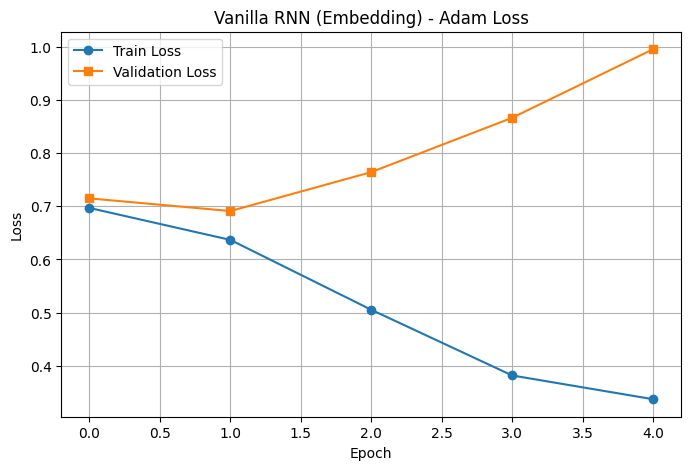

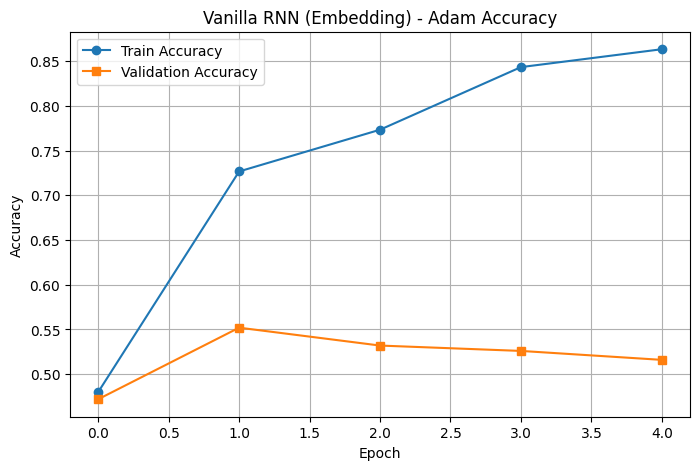

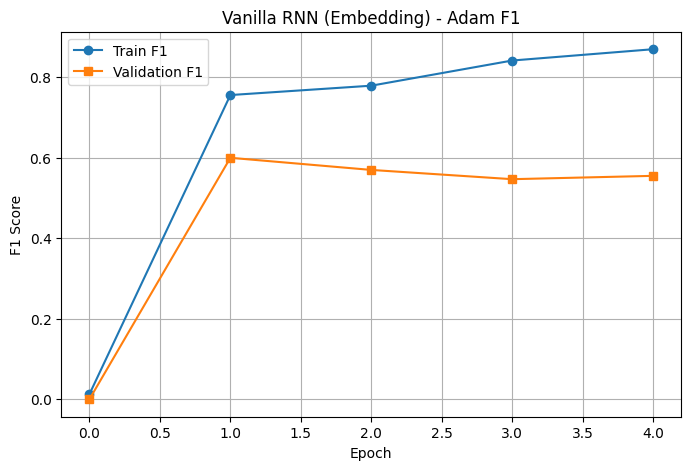

Vanilla RNN (Embedding) Test Metrics: {'loss': np.float64(0.951099574085325), 'accuracy': np.float64(0.512), 'f1': np.float64(0.5100401606420691)}


In [15]:
T = 50

X_train = prepare_sequences(x_train_raw, T)
X_val = prepare_sequences(x_val_raw, T)
X_test = prepare_sequences(x_test_raw, T)

rnn_embed = VanillaRNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    use_embedding=True
)

history_rnn_embed_adam = train_model(
    rnn_embed,
    X_train,
    y_train,
    X_val,
    y_val,
    optimizer_name="adam",
    lr=0.001,
    epochs=5
)

plot_loss_curves(history_rnn_embed_adam, title="Vanilla RNN (Embedding) - Adam Loss")
plot_accuracy_curves(history_rnn_embed_adam, title="Vanilla RNN (Embedding) - Adam Accuracy")
plot_f1_curves(history_rnn_embed_adam, title="Vanilla RNN (Embedding) - Adam F1")

test_metrics_rnn_embed = evaluate_model(rnn_embed, X_test, y_test)
print("Vanilla RNN (Embedding) Test Metrics:", test_metrics_rnn_embed)

## 19. Experiment 2: Vanilla RNN with One-Hot Encoding

We now train the Vanilla RNN using one-hot encoded input vectors.

If the vocabulary size is \(|V|\), then each word is represented as:

\[
x_t \in \mathbb{R}^{|V|}
\]

where only one entry is equal to 1 and all others are 0.

This representation is high-dimensional and sparse. It is useful for comparison because the assignment explicitly asks us to evaluate both one-hot vectors and learned embeddings.

/tmp/ipykernel_16637/1848786341.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss = float(binary_cross_entropy(y_hat, y))
/tmp/ipykernel_16637/691033615.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  losses.append(float(binary_cross_entropy(p, yy)))


Epoch 1/3 | Train Loss: 0.6890 | Val Loss: 0.6965 | Train Acc: 0.5467 | Val Acc: 0.4840 | Val F1: 0.3768
Epoch 2/3 | Train Loss: 0.6790 | Val Loss: 0.6983 | Train Acc: 0.5867 | Val Acc: 0.4880 | Val F1: 0.4361
Epoch 3/3 | Train Loss: 0.7007 | Val Loss: 0.7071 | Train Acc: 0.4833 | Val Acc: 0.4740 | Val F1: 0.0000


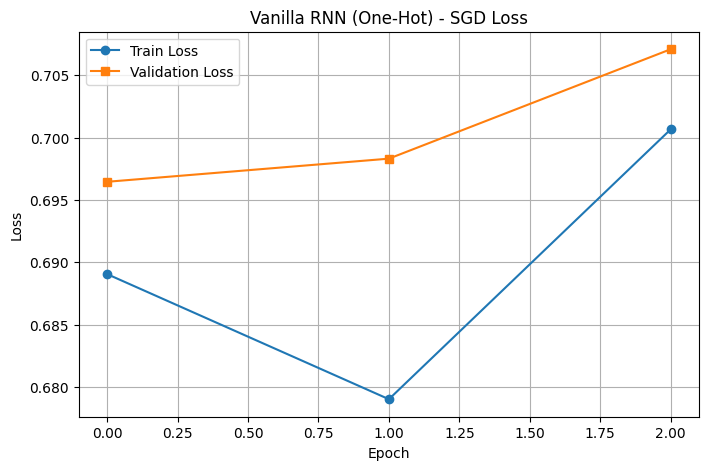

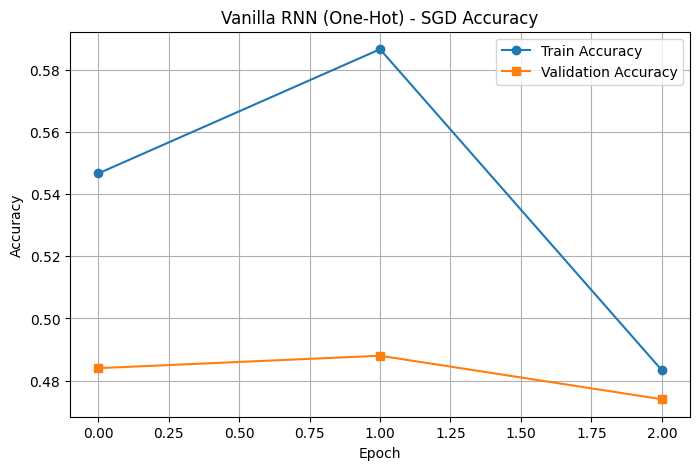

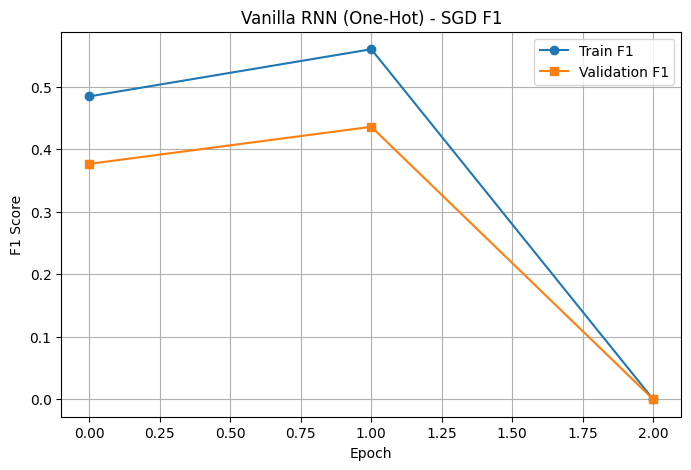

Vanilla RNN (One-Hot) Test Metrics: {'loss': np.float64(0.693890491604805), 'accuracy': np.float64(0.524), 'f1': np.float64(0.0)}


In [16]:
rnn_onehot = VanillaRNN(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    use_embedding=False
)

history_rnn_onehot_sgd = train_model(
    rnn_onehot,
    X_train,
    y_train,
    X_val,
    y_val,
    optimizer_name="sgd",
    lr=0.01,
    epochs=3
)

plot_loss_curves(history_rnn_onehot_sgd, title="Vanilla RNN (One-Hot) - SGD Loss")
plot_accuracy_curves(history_rnn_onehot_sgd, title="Vanilla RNN (One-Hot) - SGD Accuracy")
plot_f1_curves(history_rnn_onehot_sgd, title="Vanilla RNN (One-Hot) - SGD F1")

test_metrics_rnn_onehot = evaluate_model(rnn_onehot, X_test, y_test)
print("Vanilla RNN (One-Hot) Test Metrics:", test_metrics_rnn_onehot)

## 20. Experiment 3: Standard LSTM with Learned Embeddings

We now train a standard LSTM model with learned word embeddings.

Compared to the Vanilla RNN, the LSTM is expected to perform better on longer sequences because the cell state provides a more stable path for gradient flow.

/tmp/ipykernel_16637/1848786341.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss = float(binary_cross_entropy(y_hat, y))
/tmp/ipykernel_16637/691033615.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  losses.append(float(binary_cross_entropy(p, yy)))


Epoch 1/5 | Train Loss: 0.6699 | Val Loss: 0.6716 | Train Acc: 0.6067 | Val Acc: 0.5940 | Val F1: 0.4700
Epoch 2/5 | Train Loss: 0.5817 | Val Loss: 0.6815 | Train Acc: 0.7667 | Val Acc: 0.5600 | Val F1: 0.5089
Epoch 3/5 | Train Loss: 0.3421 | Val Loss: 0.6368 | Train Acc: 0.8600 | Val Acc: 0.6540 | Val F1: 0.6981
Epoch 4/5 | Train Loss: 0.2444 | Val Loss: 0.7308 | Train Acc: 0.9133 | Val Acc: 0.6460 | Val F1: 0.6210
Epoch 5/5 | Train Loss: 0.1396 | Val Loss: 0.8186 | Train Acc: 0.9567 | Val Acc: 0.6540 | Val F1: 0.6837


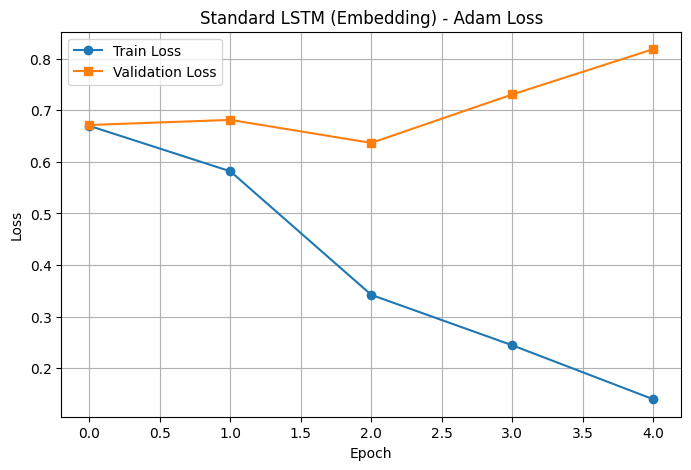

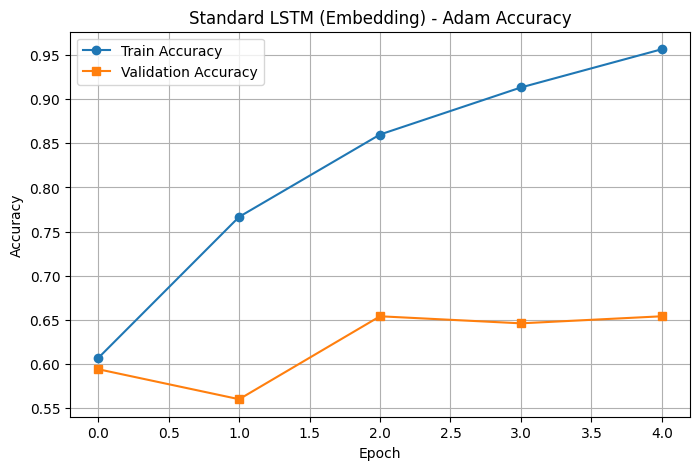

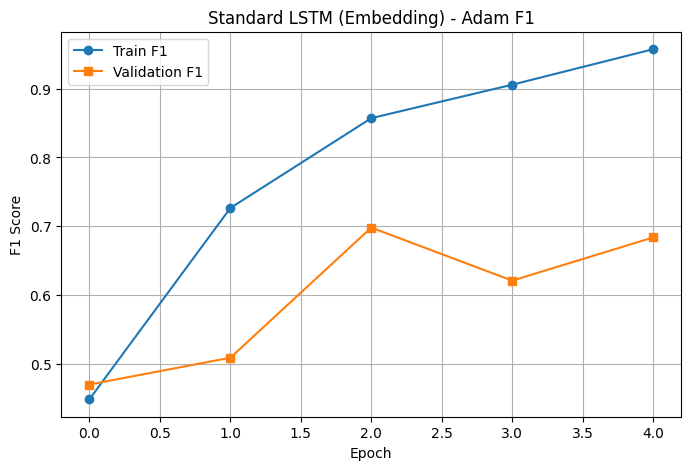

Standard LSTM (Embedding) Test Metrics: {'loss': np.float64(0.7385269502936862), 'accuracy': np.float64(0.674), 'f1': np.float64(0.6785009861927931)}


In [17]:
lstm_embed = LSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    use_embedding=True,
    coupled=False
)

history_lstm_embed_adam = train_model(
    lstm_embed,
    X_train,
    y_train,
    X_val,
    y_val,
    optimizer_name="adam",
    lr=0.001,
    epochs=5
)

plot_loss_curves(history_lstm_embed_adam, title="Standard LSTM (Embedding) - Adam Loss")
plot_accuracy_curves(history_lstm_embed_adam, title="Standard LSTM (Embedding) - Adam Accuracy")
plot_f1_curves(history_lstm_embed_adam, title="Standard LSTM (Embedding) - Adam F1")

test_metrics_lstm_embed = evaluate_model(lstm_embed, X_test, y_test)
print("Standard LSTM (Embedding) Test Metrics:", test_metrics_lstm_embed)

## 21. Experiment 4: Coupled Input-Forget Gate LSTM

In this variant, the input gate is not learned independently. Instead, it is coupled with the forget gate:

\[
i_t = 1 - f_t
\]

Thus, the cell state update becomes:

\[
C_t = f_t \odot C_{t-1} + (1-f_t) \odot \tilde{C}_t
\]

This reduces the number of parameters and forces the model to input new information only when old information is forgotten.

We compare this coupled-gate variant with the standard LSTM in terms of:

- training time
- convergence behavior
- final accuracy

/tmp/ipykernel_16637/1848786341.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss = float(binary_cross_entropy(y_hat, y))
/tmp/ipykernel_16637/691033615.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  losses.append(float(binary_cross_entropy(p, yy)))


Epoch 1/5 | Train Loss: 0.6614 | Val Loss: 0.6834 | Train Acc: 0.6467 | Val Acc: 0.5640 | Val F1: 0.5496
Epoch 2/5 | Train Loss: 0.3971 | Val Loss: 0.6721 | Train Acc: 0.8333 | Val Acc: 0.6600 | Val F1: 0.7302
Epoch 3/5 | Train Loss: 0.2377 | Val Loss: 0.7160 | Train Acc: 0.9167 | Val Acc: 0.6740 | Val F1: 0.7020
Epoch 4/5 | Train Loss: 0.1382 | Val Loss: 0.9219 | Train Acc: 0.9567 | Val Acc: 0.6480 | Val F1: 0.6835
Epoch 5/5 | Train Loss: 0.1215 | Val Loss: 1.3191 | Train Acc: 0.9533 | Val Acc: 0.6380 | Val F1: 0.6978


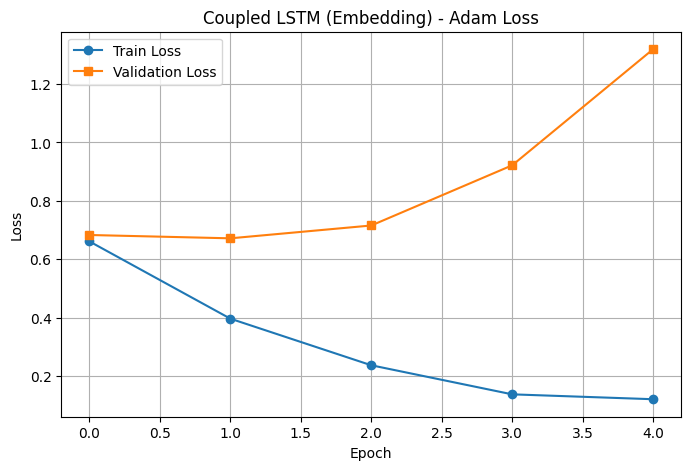

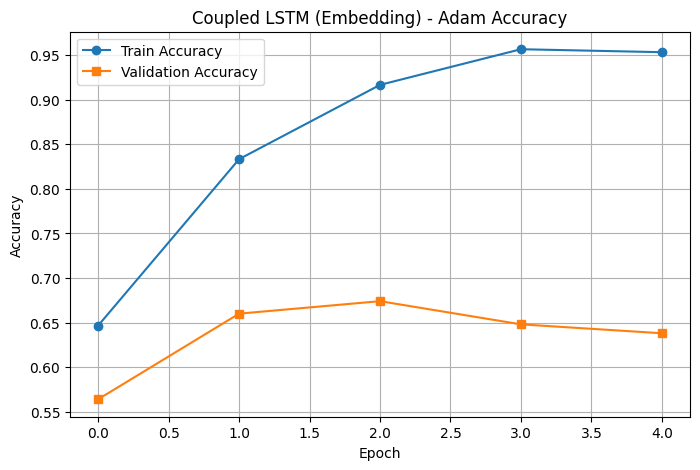

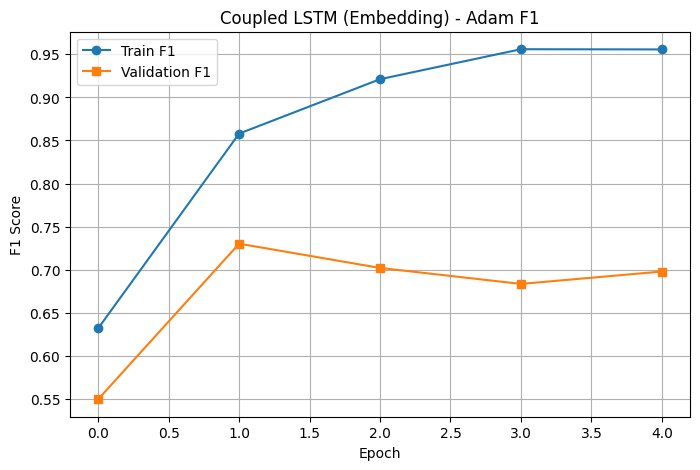

Coupled LSTM Test Metrics: {'loss': np.float64(1.1048006564739334), 'accuracy': np.float64(0.67), 'f1': np.float64(0.7027027027022102)}
Coupled LSTM Training Time (sec): 397.62702798843384


In [18]:
coupled_lstm = LSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    use_embedding=True,
    coupled=True
)

start_time = time.time()
history_coupled_lstm = train_model(
    coupled_lstm,
    X_train,
    y_train,
    X_val,
    y_val,
    optimizer_name="adam",
    lr=0.001,
    epochs=5
)
coupled_time = time.time() - start_time

plot_loss_curves(history_coupled_lstm, title="Coupled LSTM (Embedding) - Adam Loss")
plot_accuracy_curves(history_coupled_lstm, title="Coupled LSTM (Embedding) - Adam Accuracy")
plot_f1_curves(history_coupled_lstm, title="Coupled LSTM (Embedding) - Adam F1")

test_metrics_coupled_lstm = evaluate_model(coupled_lstm, X_test, y_test)
print("Coupled LSTM Test Metrics:", test_metrics_coupled_lstm)
print("Coupled LSTM Training Time (sec):", coupled_time)

## 22. Experiment 5: Standard LSTM with SGD

This experiment trains the standard LSTM using plain SGD so that it can later be compared directly against Adam.

The goal is to analyze how optimizer choice affects convergence on the more complex loss surface of recurrent architectures.

/tmp/ipykernel_16637/1848786341.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss = float(binary_cross_entropy(y_hat, y))
/tmp/ipykernel_16637/691033615.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  losses.append(float(binary_cross_entropy(p, yy)))


Epoch 1/5 | Train Loss: 0.6936 | Val Loss: 0.6920 | Train Acc: 0.5000 | Val Acc: 0.5260 | Val F1: 0.6894
Epoch 2/5 | Train Loss: 0.6936 | Val Loss: 0.6921 | Train Acc: 0.4967 | Val Acc: 0.5260 | Val F1: 0.6894
Epoch 3/5 | Train Loss: 0.6982 | Val Loss: 0.6919 | Train Acc: 0.4733 | Val Acc: 0.5260 | Val F1: 0.6894
Epoch 4/5 | Train Loss: 0.6935 | Val Loss: 0.6939 | Train Acc: 0.4867 | Val Acc: 0.4740 | Val F1: 0.0000
Epoch 5/5 | Train Loss: 0.6922 | Val Loss: 0.6919 | Train Acc: 0.5200 | Val Acc: 0.5260 | Val F1: 0.6894


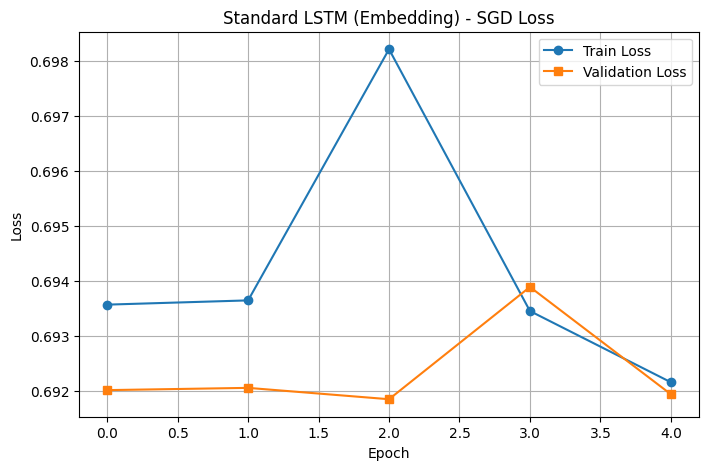

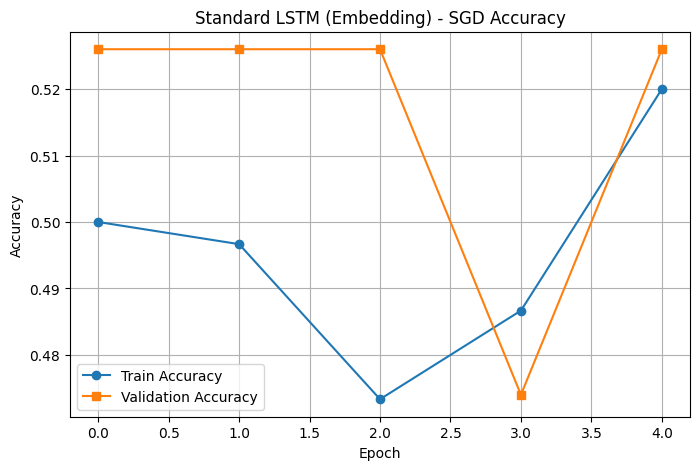

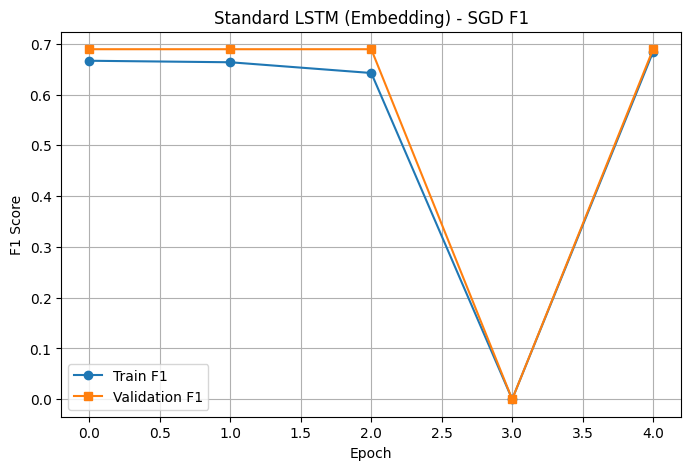

Standard LSTM (SGD) Test Metrics: {'loss': np.float64(0.6952865705490112), 'accuracy': np.float64(0.476), 'f1': np.float64(0.6449864498640598)}


In [19]:
lstm_sgd = LSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    use_embedding=True,
    coupled=False
)

history_lstm_sgd = train_model(
    lstm_sgd,
    X_train,
    y_train,
    X_val,
    y_val,
    optimizer_name="sgd",
    lr=0.01,
    epochs=5
)

plot_loss_curves(history_lstm_sgd, title="Standard LSTM (Embedding) - SGD Loss")
plot_accuracy_curves(history_lstm_sgd, title="Standard LSTM (Embedding) - SGD Accuracy")
plot_f1_curves(history_lstm_sgd, title="Standard LSTM (Embedding) - SGD F1")

test_metrics_lstm_sgd = evaluate_model(lstm_sgd, X_test, y_test)
print("Standard LSTM (SGD) Test Metrics:", test_metrics_lstm_sgd)

## 23. Ablation A: Vanishing Gradient in Action

One of the most important weaknesses of the Vanilla RNN is the vanishing gradient problem.

To demonstrate this empirically, we measure the magnitude of:

\[
\left\| \frac{\partial L}{\partial h_1} \right\|
\]

for different sequence lengths:

- \(T = 5\)
- \(T = 20\)
- \(T = 50\)

### Why does the gradient vanish in a Vanilla RNN?

In a Vanilla RNN, the gradient to early time steps involves repeated multiplication by recurrent Jacobians:

\[
\prod_{j=k+1}^{T} \frac{\partial h_j}{\partial h_{j-1}}
\]

Since

\[
h_t = \tanh(a_t)
\]

we have

\[
\frac{\partial h_t}{\partial a_t} = 1 - h_t^2
\]

and the entries of \(1-h_t^2\) are bounded above by 1. Therefore, repeated multiplication across many time steps tends to shrink the gradient exponentially.

### Why is the LSTM more stable?

In the LSTM, the cell state update is additive:

\[
C_t = f_t \odot C_{t-1} + i_t \odot \tilde{C}_t
\]

This additive pathway makes it easier for gradients to flow backward without repeatedly shrinking as severely as in the Vanilla RNN.

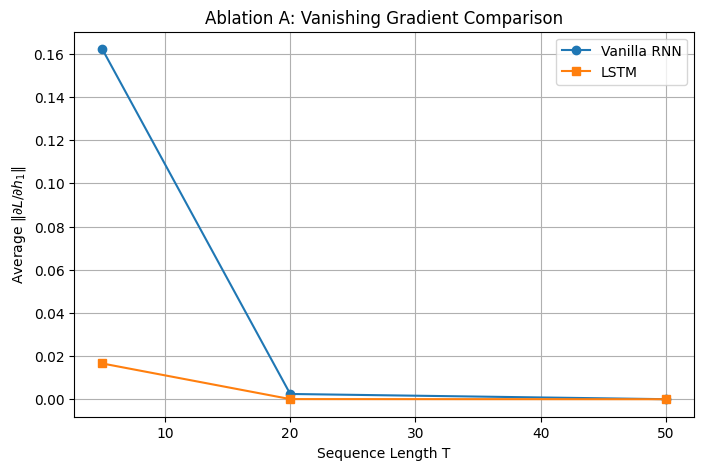

Vanilla RNN grad magnitudes: [np.float64(0.16213586712234815), np.float64(0.0024360006527225867), np.float64(1.2358026146679917e-05)]
LSTM grad magnitudes: [np.float64(0.016555754978826952), np.float64(5.7757367072363705e-05), np.float64(3.896414952496207e-10)]


In [20]:
def collect_h1_gradient_magnitude(model_class, seq_lengths, use_embedding=True, coupled=False):
    grad_mags = []

    for T in seq_lengths:
        X_small = prepare_sequences(x_train_raw[:50], T)
        y_small = y_train[:50]

        if model_class == VanillaRNN:
            model = model_class(
                vocab_size=VOCAB_SIZE,
                embed_dim=EMBED_DIM,
                hidden_dim=HIDDEN_DIM,
                use_embedding=use_embedding
            )
        else:
            model = model_class(
                vocab_size=VOCAB_SIZE,
                embed_dim=EMBED_DIM,
                hidden_dim=HIDDEN_DIM,
                use_embedding=use_embedding,
                coupled=coupled
            )

        sample_grad_mags = []

        for i in range(len(X_small)):
            seq = X_small[i]
            label = y_small[i]
            y = np.array([[label]], dtype=np.float32)

            y_hat, cache = model.forward(seq)
            grads, grad_h1_mag = model.backward(y, cache, clip_value=5.0)

            if grad_h1_mag is not None:
                sample_grad_mags.append(grad_h1_mag)

        grad_mags.append(np.mean(sample_grad_mags))

    return grad_mags


rnn_grad_mags = collect_h1_gradient_magnitude(VanillaRNN, SEQ_LENGTHS, use_embedding=True)
lstm_grad_mags = collect_h1_gradient_magnitude(LSTM, SEQ_LENGTHS, use_embedding=True, coupled=False)

plt.figure(figsize=(8, 5))
plt.plot(SEQ_LENGTHS, rnn_grad_mags, marker='o', label="Vanilla RNN")
plt.plot(SEQ_LENGTHS, lstm_grad_mags, marker='s', label="LSTM")
plt.xlabel("Sequence Length T")
plt.ylabel(r"Average $\|\partial L / \partial h_1\|$")
plt.title("Ablation A: Vanishing Gradient Comparison")
plt.legend()
plt.grid(True)
plt.show()

print("Vanilla RNN grad magnitudes:", rnn_grad_mags)
print("LSTM grad magnitudes:", lstm_grad_mags)

## 24. Ablation B: Standard LSTM vs Coupled Gate LSTM

In this ablation, we compare:

- Standard LSTM
- Coupled input-forget gate LSTM

The coupled version reduces the number of parameters because the input gate is removed as an independent gate.

We compare:

1. Training time
2. Convergence speed
3. Final test accuracy
4. Final test F1-score

This experiment helps us understand whether reducing parameter count improves efficiency without significantly hurting predictive performance.

In [21]:
standard_lstm_for_ablation = LSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    use_embedding=True,
    coupled=False
)

start_standard = time.time()
history_standard_ablation = train_model(
    standard_lstm_for_ablation,
    X_train,
    y_train,
    X_val,
    y_val,
    optimizer_name="adam",
    lr=0.001,
    epochs=5
)
time_standard = time.time() - start_standard

standard_test = evaluate_model(standard_lstm_for_ablation, X_test, y_test)

coupled_lstm_for_ablation = LSTM(
    vocab_size=VOCAB_SIZE,
    embed_dim=EMBED_DIM,
    hidden_dim=HIDDEN_DIM,
    use_embedding=True,
    coupled=True
)

start_coupled = time.time()
history_coupled_ablation = train_model(
    coupled_lstm_for_ablation,
    X_train,
    y_train,
    X_val,
    y_val,
    optimizer_name="adam",
    lr=0.001,
    epochs=5
)
time_coupled = time.time() - start_coupled

coupled_test = evaluate_model(coupled_lstm_for_ablation, X_test, y_test)

print("Standard LSTM Test:", standard_test)
print("Coupled LSTM Test:", coupled_test)
print("Standard LSTM Training Time:", time_standard)
print("Coupled LSTM Training Time:", time_coupled)

/tmp/ipykernel_16637/1848786341.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss = float(binary_cross_entropy(y_hat, y))
/tmp/ipykernel_16637/691033615.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  losses.append(float(binary_cross_entropy(p, yy)))


Epoch 1/5 | Train Loss: 0.6879 | Val Loss: 0.6903 | Train Acc: 0.5967 | Val Acc: 0.5260 | Val F1: 0.5635
Epoch 2/5 | Train Loss: 0.5710 | Val Loss: 0.6486 | Train Acc: 0.7300 | Val Acc: 0.6480 | Val F1: 0.6271
Epoch 3/5 | Train Loss: 0.4000 | Val Loss: 0.7432 | Train Acc: 0.7967 | Val Acc: 0.5980 | Val F1: 0.5400
Epoch 4/5 | Train Loss: 0.2094 | Val Loss: 0.7804 | Train Acc: 0.9267 | Val Acc: 0.6740 | Val F1: 0.6707
Epoch 5/5 | Train Loss: 0.1294 | Val Loss: 0.8652 | Train Acc: 0.9767 | Val Acc: 0.6600 | Val F1: 0.6705
Epoch 1/5 | Train Loss: 0.7040 | Val Loss: 0.6932 | Train Acc: 0.5000 | Val Acc: 0.5280 | Val F1: 0.6903
Epoch 2/5 | Train Loss: 0.4954 | Val Loss: 0.6771 | Train Acc: 0.7700 | Val Acc: 0.6400 | Val F1: 0.5833
Epoch 3/5 | Train Loss: 0.2748 | Val Loss: 0.7376 | Train Acc: 0.9033 | Val Acc: 0.6380 | Val F1: 0.6189
Epoch 4/5 | Train Loss: 0.1887 | Val Loss: 0.7336 | Train Acc: 0.9333 | Val Acc: 0.6460 | Val F1: 0.6495
Epoch 5/5 | Train Loss: 0.1476 | Val Loss: 0.9453 | Tra

## 25. Ablation C: Optimization Strategies

In this ablation, we compare the loss curves of:

- Standard LSTM trained with SGD
- Standard LSTM trained with Adam

This experiment is designed to answer the question:

**How does Adam compare to standard SGD when optimizing the complex loss surface of an LSTM?**

In practice, Adam is often expected to converge faster and more smoothly because it adapts the step size for each parameter using moment estimates.

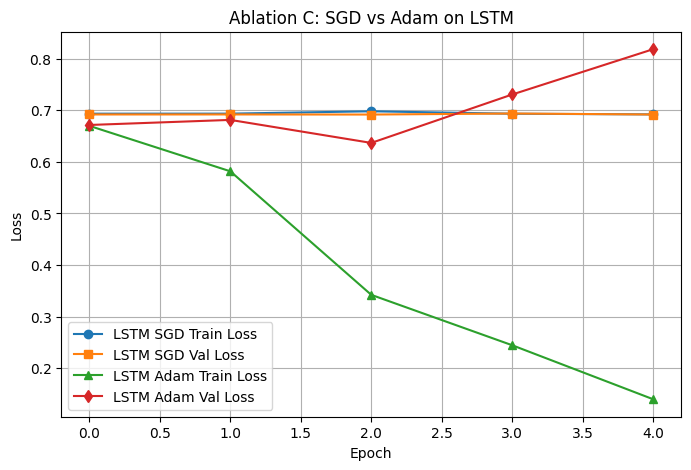

In [22]:
plt.figure(figsize=(8, 5))
plt.plot(history_lstm_sgd["train_loss"], marker='o', label="LSTM SGD Train Loss")
plt.plot(history_lstm_sgd["val_loss"], marker='s', label="LSTM SGD Val Loss")
plt.plot(history_lstm_embed_adam["train_loss"], marker='^', label="LSTM Adam Train Loss")
plt.plot(history_lstm_embed_adam["val_loss"], marker='d', label="LSTM Adam Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Ablation C: SGD vs Adam on LSTM")
plt.legend()
plt.grid(True)
plt.show()

## 26. Final Results Summary

We now summarize the final performance of the main models in a table.

The reported quantities are:

- Test Accuracy
- Test F1-score

This allows direct comparison across architectures, input representations, and optimizers.

In [23]:
results = []

results.append([
    "Vanilla RNN", "Embedding", 50, "Adam",
    test_metrics_rnn_embed["accuracy"], test_metrics_rnn_embed["f1"]
])

results.append([
    "Vanilla RNN", "One-Hot", 50, "SGD",
    test_metrics_rnn_onehot["accuracy"], test_metrics_rnn_onehot["f1"]
])

results.append([
    "Standard LSTM", "Embedding", 50, "Adam",
    test_metrics_lstm_embed["accuracy"], test_metrics_lstm_embed["f1"]
])

results.append([
    "Coupled LSTM", "Embedding", 50, "Adam",
    test_metrics_coupled_lstm["accuracy"], test_metrics_coupled_lstm["f1"]
])

results.append([
    "Standard LSTM", "Embedding", 50, "SGD",
    test_metrics_lstm_sgd["accuracy"], test_metrics_lstm_sgd["f1"]
])

print(f"{'Model':<20} {'Input':<12} {'T':<5} {'Optimizer':<10} {'Accuracy':<12} {'F1':<12}")
print("-" * 75)
for row in results:
    print(f"{row[0]:<20} {row[1]:<12} {row[2]:<5} {row[3]:<10} {row[4]:<12.4f} {row[5]:<12.4f}")

Model                Input        T     Optimizer  Accuracy     F1          
---------------------------------------------------------------------------
Vanilla RNN          Embedding    50    Adam       0.5120       0.5100      
Vanilla RNN          One-Hot      50    SGD        0.5240       0.0000      
Standard LSTM        Embedding    50    Adam       0.6740       0.6785      
Coupled LSTM         Embedding    50    Adam       0.6700       0.7027      
Standard LSTM        Embedding    50    SGD        0.4760       0.6450      


## 27. Sequence Length Comparison

The assignment requires comparing performance across different sequence lengths.

We therefore run experiments for:

- \(T = 5\)
- \(T = 20\)
- \(T = 50\)

This helps us understand how much useful information the models can capture when the length of the available context changes.

In [24]:
def run_sequence_length_experiment(model_name="rnn", optimizer_name="adam", use_embedding=True):
    output = []

    for T in SEQ_LENGTHS:
        X_train_T = prepare_sequences(x_train_raw, T)
        X_val_T = prepare_sequences(x_val_raw, T)
        X_test_T = prepare_sequences(x_test_raw, T)

        if model_name == "rnn":
            model = VanillaRNN(
                vocab_size=VOCAB_SIZE,
                embed_dim=EMBED_DIM,
                hidden_dim=HIDDEN_DIM,
                use_embedding=use_embedding
            )
        elif model_name == "lstm":
            model = LSTM(
                vocab_size=VOCAB_SIZE,
                embed_dim=EMBED_DIM,
                hidden_dim=HIDDEN_DIM,
                use_embedding=use_embedding,
                coupled=False
            )
        else:
            raise ValueError("model_name must be 'rnn' or 'lstm'")

        lr = 0.001 if optimizer_name == "adam" else 0.01

        history = train_model(
            model,
            X_train_T,
            y_train,
            X_val_T,
            y_val,
            optimizer_name=optimizer_name,
            lr=lr,
            epochs=3
        )

        metrics = evaluate_model(model, X_test_T, y_test)
        output.append((T, metrics["accuracy"], metrics["f1"]))

    return output


rnn_seq_results = run_sequence_length_experiment(model_name="rnn", optimizer_name="adam", use_embedding=True)
lstm_seq_results = run_sequence_length_experiment(model_name="lstm", optimizer_name="adam", use_embedding=True)

print("RNN sequence length results:", rnn_seq_results)
print("LSTM sequence length results:", lstm_seq_results)

/tmp/ipykernel_16637/1848786341.py:33: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  loss = float(binary_cross_entropy(y_hat, y))
/tmp/ipykernel_16637/691033615.py:22: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  losses.append(float(binary_cross_entropy(p, yy)))


Epoch 1/3 | Train Loss: 0.7132 | Val Loss: 0.7183 | Train Acc: 0.5233 | Val Acc: 0.5260 | Val F1: 0.5651
Epoch 2/3 | Train Loss: 0.5375 | Val Loss: 0.7360 | Train Acc: 0.7500 | Val Acc: 0.5320 | Val F1: 0.5634
Epoch 3/3 | Train Loss: 0.4226 | Val Loss: 0.7777 | Train Acc: 0.8233 | Val Acc: 0.5540 | Val F1: 0.5636
Epoch 1/3 | Train Loss: 0.6965 | Val Loss: 0.7043 | Train Acc: 0.5200 | Val Acc: 0.4740 | Val F1: 0.0000
Epoch 2/3 | Train Loss: 0.6847 | Val Loss: 0.6990 | Train Acc: 0.5433 | Val Acc: 0.5280 | Val F1: 0.6878
Epoch 3/3 | Train Loss: 0.5901 | Val Loss: 0.6975 | Train Acc: 0.6967 | Val Acc: 0.5460 | Val F1: 0.6079
Epoch 1/3 | Train Loss: 0.6998 | Val Loss: 0.7064 | Train Acc: 0.4967 | Val Acc: 0.4740 | Val F1: 0.0000
Epoch 2/3 | Train Loss: 0.6726 | Val Loss: 0.6949 | Train Acc: 0.5600 | Val Acc: 0.5080 | Val F1: 0.6404
Epoch 3/3 | Train Loss: 0.4985 | Val Loss: 0.7274 | Train Acc: 0.7833 | Val Acc: 0.5420 | Val F1: 0.6031
Epoch 1/3 | Train Loss: 0.6686 | Val Loss: 0.6878 | Tra

## 28. Accuracy as a Function of Sequence Length

Finally, we plot test accuracy against sequence length for both the Vanilla RNN and the LSTM.

This plot gives a compact visual summary of how each architecture behaves as the sequence becomes longer.

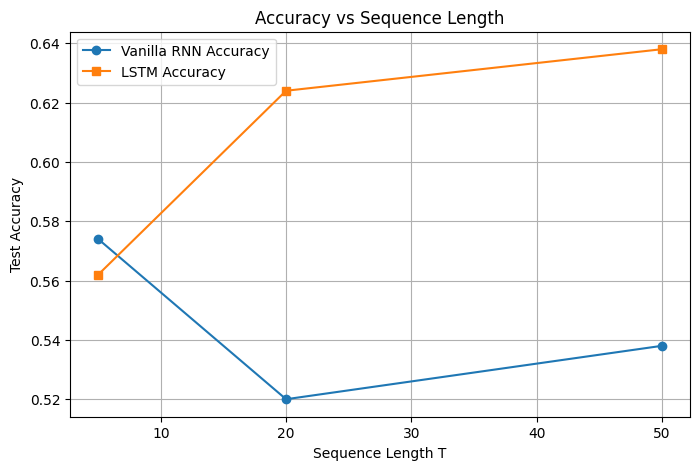

In [25]:
rnn_T = [x[0] for x in rnn_seq_results]
rnn_acc = [x[1] for x in rnn_seq_results]

lstm_T = [x[0] for x in lstm_seq_results]
lstm_acc = [x[1] for x in lstm_seq_results]

plt.figure(figsize=(8, 5))
plt.plot(rnn_T, rnn_acc, marker='o', label="Vanilla RNN Accuracy")
plt.plot(lstm_T, lstm_acc, marker='s', label="LSTM Accuracy")
plt.xlabel("Sequence Length T")
plt.ylabel("Test Accuracy")
plt.title("Accuracy vs Sequence Length")
plt.legend()
plt.grid(True)
plt.show()